# AgeLens

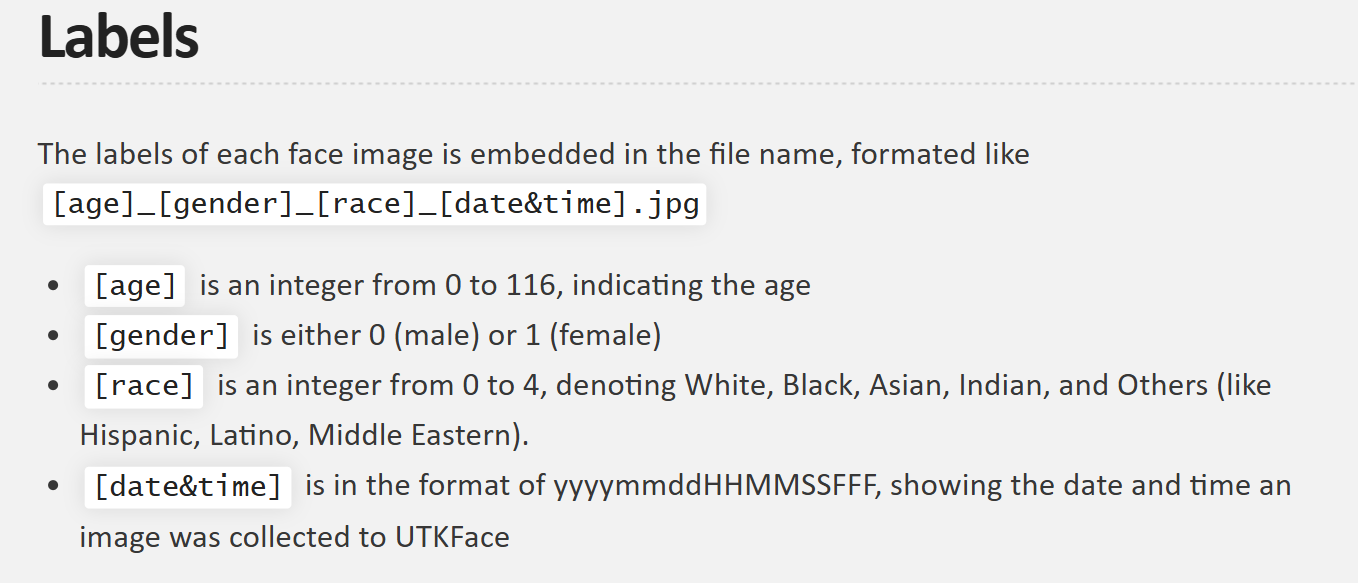

In [1]:
!pip install tensorflow
!pip install kagglehub


In [2]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jangedoo/utkface-new")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'utkface-new' dataset.
Path to dataset files: /kaggle/input/utkface-new


In [4]:
#Extrahiere Datenset bzw bekomme die labels

In [5]:
import gzip
import numpy as np
from keras.utils import to_categorical


In [6]:
dataset_folder_name = ''

TRAIN_TEST_SPLIT = 0.7
IM_WIDTH = IM_HEIGHT = 198

dataset_dict = {
    'race_id': {
        0: 'white',
        1: 'black',
        2: 'asian',
        3: 'indian',
        4: 'others'
    },
    'gender_id': {
        0: 'male',
        1: 'female'
    }
}

dataset_dict['gender_alias'] = dict((g, i) for i, g in dataset_dict['gender_id'].items())
dataset_dict['race_alias'] = dict((g, i) for i, g in dataset_dict['race_id'].items())

In [7]:
import pandas as pd
import os

def parse_dataset(dataset_path):
    records = []

    # Sicherstellen, dass der Pfad existiert
    if not os.path.exists(dataset_path):
        print(f"Pfad nicht gefunden: {dataset_path}")
        return pd.DataFrame()

    for file in os.listdir(dataset_path):
        if file.endswith(".jpg"):
            try:
                # Splittet den Dateinamen: "age_gender_race_date.jpg"
                parts = file.split("_")

                # Wir brauchen mindestens 3 Teile (age, gender, race)
                if len(parts) >= 3:
                    age = int(parts[0])
                    gender = int(parts[1])
                    race = int(parts[2])
                    file_path = os.path.join(dataset_path, file)

                    # Wir fügen ein Dictionary hinzu – das erkennt Pandas automatisch als Zeile
                    records.append({
                        'age': age,
                        'gender': gender,
                        'race': race,
                        'file': file_path
                    })
            except (ValueError, IndexError):
                # Falls ein Dateiname nicht dem Schema entspricht, einfach überspringen
                continue

    df = pd.DataFrame(records)

    return df





In [8]:
import numpy as np
import pandas as pd
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
def parse_dataset(dataset_path, ext='jpg'):
    """
    Used to extract information about our dataset. It does iterate over all images and return a DataFrame with
    the data (age, gender and sex) of all files.
    """
    def parse_info_from_file(path):
        """
        Parse information from a single file
        """
        try:
            filename = os.path.split(path)[1]
            filename = os.path.splitext(filename)[0]
            age, gender, race, _ = filename.split('_')

            return int(age), dataset_dict['gender_id'][int(gender)], dataset_dict['race_id'][int(race)]
        except Exception as ex:
            return None, None, None

    files = glob.glob(os.path.join(dataset_path, "*.%s" % ext))

    records = []
    for file in files:
        info = parse_info_from_file(file)
        records.append(info)

    df = pd.DataFrame(records)

    df['file'] = files
    df.columns = ['age', 'gender', 'race', 'file']
    df = df.dropna()


    return df

In [10]:
!pip install scikit-learn

In [11]:
import os
import glob
import numpy as np
import pandas as pd
from PIL import Image
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

# --- FUNKTIONEN ---

def load_data_and_labels(base_path, target_size=(28, 28)):
    if not os.path.exists(base_path):
        print(f"FEHLER: Der Pfad {base_path} existiert nicht.")
        return np.array([]), pd.DataFrame()

    files = glob.glob(os.path.join(base_path, "*.jpg"))
    if not files:
        files = glob.glob(os.path.join(base_path, "*.JPG"))

    files = list(set(files))
    images = []
    labels = []

    print(f"Dateien gefunden: {len(files)}")

    for f in files:
        basename = os.path.basename(f)
        parts = basename.split('_')

        if len(parts) >= 3:
            try:
                age = int(parts[0])
                gender = int(parts[1])
                race = int(parts[2])

                img = Image.open(f).convert('L')
                img = img.resize(target_size, Image.Resampling.LANCZOS)

                images.append(np.array(img))
                labels.append({'age': age, 'gender': gender, 'race': race})
            except Exception:
                continue

    if not images:
        print("FEHLER: Keine gültigen Daten gefunden.")
        return np.array([]), pd.DataFrame()

    X = np.array(images).astype('float32') / 255.0
    X = X.reshape(-1, target_size[0], target_size[1], 1)
    y = pd.DataFrame(labels)

    print(f"Erfolgreich verarbeitet: {len(X)} Bilder")
    return X, y

def prepare_multi_output_labels(df):
    """Konvertiert den DataFrame in eine Liste für Keras-Multi-Output."""
    gender = to_categorical(df['gender'], num_classes=2)
    race = to_categorical(df['race'], num_classes=5)
    age = df['age'].values.astype('float32')
    return [gender, race, age]

# --- HAUPTPROGRAMM ---

dataset_path = '/kaggle/input/utkface-new/UTKFace'
seed = 42

# 1. Daten laden
X_all, y_all = load_data_and_labels(dataset_path)

# 2. Split und Label-Vorbereitung
if len(X_all) > 0:
    # 70% Train, 30% Rest
    X_train, X_temp, y_train, y_temp = train_test_split(
        X_all, y_all, test_size=0.30, random_state=seed, stratify=y_all['gender']
    )

    # Rest aufteilen in 15% Val und 15% Test
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.50, random_state=seed, stratify=y_temp['gender']
    )

    # 3. Multi-Output Labels erstellen
    y_train_multi = prepare_multi_output_labels(y_train)
    y_val_multi = prepare_multi_output_labels(y_val)
    y_test_multi = prepare_multi_output_labels(y_test)

    print("-" * 30)
    print(f"Split & Vorbereitung abgeschlossen:")
    print(f"Train: {X_train.shape[0]} Bilder")
    print(f"Val:   {X_val.shape[0]} Bilder")
    print(f"Test:  {X_test.shape[0]} Bilder")
    print("-" * 30)
    print("Labels für das Modell bereit (Gender, Race, Age).")
else:
    print("Abbruch: Keine Daten zum Verarbeiten vorhanden.")

Dateien gefunden: 23708
Erfolgreich verarbeitet: 23705 Bilder
------------------------------
Split & Vorbereitung abgeschlossen:
Train: 16593 Bilder
Val:   3556 Bilder
Test:  3556 Bilder
------------------------------
Labels für das Modell bereit (Gender, Race, Age).


# Visualize Dataset

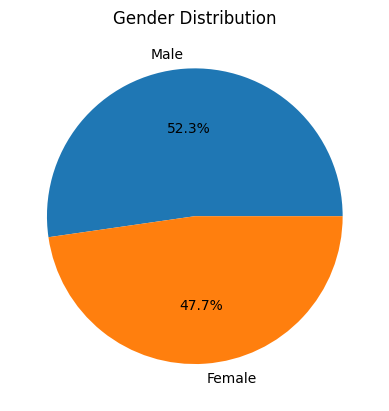

In [13]:
import matplotlib.pyplot as plt

gender_counts = y_all['gender'].value_counts()

labels = ['Male', 'Female']

plt.figure()
plt.pie(gender_counts, labels=labels, autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

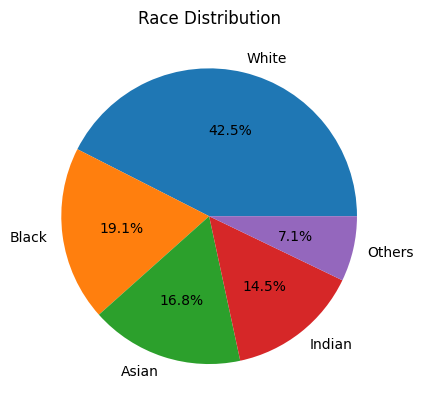

In [14]:
race_counts = y_all['race'].value_counts()

race_labels = ['White', 'Black', 'Asian', 'Indian', 'Others']

plt.figure()
plt.pie(race_counts, labels=race_labels, autopct='%1.1f%%')
plt.title("Race Distribution")
plt.show()

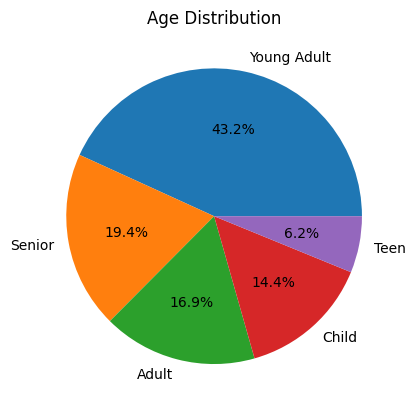

In [17]:
# Altersgruppen
#Kuchendiagramm
bins = [0, 12, 20, 35, 50, 100]
labels = ['Child', 'Teen', 'Young Adult', 'Adult', 'Senior']

y_all['age_group'] = pd.cut(y_all['age'], bins=bins, labels=labels)

age_counts = y_all['age_group'].value_counts()

plt.figure()
plt.pie(age_counts, labels=age_counts.index, autopct='%1.1f%%')
plt.title("Age Distribution")
plt.show()



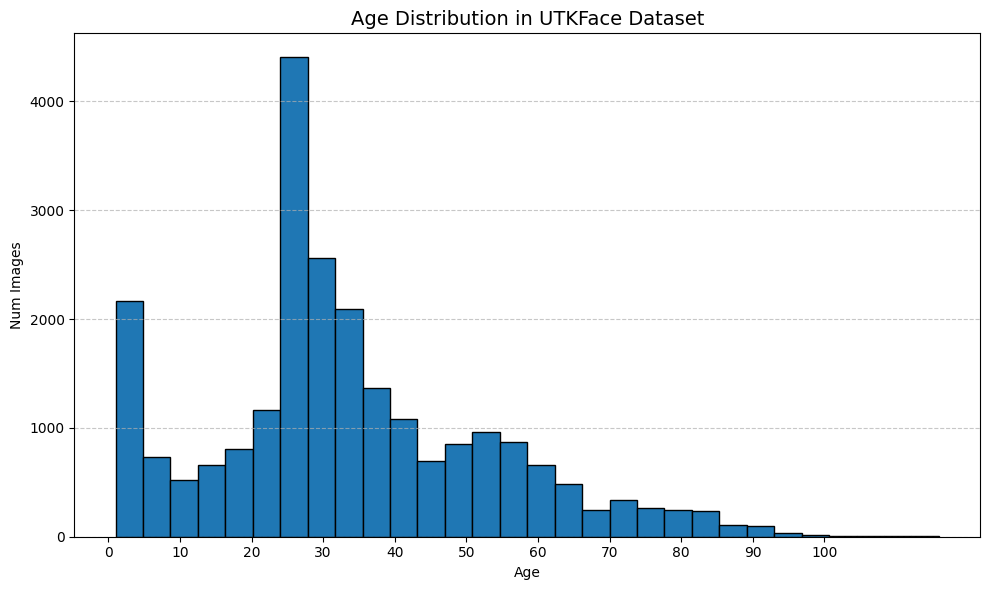

In [24]:
#Histogramm alter
plt.figure(figsize=(10,6))

plt.hist(
    y_all['age'], bins=30, edgecolor='black',
)

plt.xlabel("Age")
plt.ylabel("Num Images")
plt.title("Age Distribution in UTKFace Dataset", fontsize=14)
plt.xticks(np.arange(0, 101, 10))  # alle 10 Jahre

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# **Model Training**


In [25]:
from keras.models import Model
from keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization

# --- 1. NEUE CNN-MODELL-ARCHITEKTUR ---

# Eingangsschicht: (28, 28, 1) - Graustufenbilder
inputs = Input(shape=(28, 28, 1))

# --- Feature Extraction (Der "Seh"-Teil des Netzes) ---

# Block 1: Erkennt einfache Kanten
x = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = BatchNormalization()(x) # Normalisiert Daten für schnelleres Lernen
x = MaxPooling2D((2, 2))(x) # Halbiert die Bildgröße auf 14x14

# Block 2: Erkennt komplexere Formen
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x) # Halbiert auf 7x7

# Block 3: Erkennt Gesichtsmerkmale
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2))(x) # Halbiert auf 3x3

# --- Flachklopfen für die Interpretation ---
x = Flatten()(x) # Verwandelt die Merkmale in einen Vektor

# Gemeinsame Dense-Schicht (Interpretation der Merkmale)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x) # Starker Dropout gegen Overfitting

# --- Die drei spezialisierten Ausgänge (Heads) ---

# 1. Gender Kopf: 2 Neuronen (Softmax für Klassifikation)
gender_output = Dense(2, activation='softmax', name='gender_out')(x)

# 2. Race Kopf: 5 Neuronen (Softmax für Klassifikation)
race_output = Dense(5, activation='softmax', name='race_out')(x)

# 3. Age Kopf: 1 Neuron (Linear für Regression)
# Tipp: Manchmal hilft hier eine eigene kleine Dense-Schicht vorher
age_branch = Dense(64, activation='relu')(x)
age_output = Dense(1, activation='linear', name='age_out')(age_branch)

# Das Modell zusammenfügen
cnn_model = Model(inputs=inputs, outputs=[gender_output, race_output, age_output])

# Modellübersicht anzeigen
cnn_model.summary()

# --- 2. KOMPILIEREN (bleibt fast gleich) ---

cnn_model.compile(
    optimizer='adam', # Adam ist hier sehr gut
    loss={
        'gender_out': 'categorical_crossentropy',
        'race_out': 'categorical_crossentropy',
        'age_out': 'mse'
    },
    metrics={
        'gender_out': 'accuracy',
        'race_out': 'accuracy',
        'age_out': 'mae' # MAE ist für uns Menschen besser lesbar
    }
)

# --- 3. TRAINING (Datenübergabe bleibt gleich) ---

history = cnn_model.fit(
    X_train,
    {
        'gender_out': y_train_multi[0],
        'race_out': y_train_multi[1],
        'age_out': y_train_multi[2]
    },
    validation_data=(X_val, {
        'gender_out': y_val_multi[0],
        'race_out': y_val_multi[1],
        'age_out': y_val_multi[2]
    }),
    epochs=30, # CNNs lernen oft schneller, 30 Epochs könnten reichen
    batch_size=64 # Kleinere Batches helfen dem Optimizer
)

cnn_model.save('AgeLens_CNN_Modell.keras')

print('Training Fertig')

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 28, 28, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 28, 28,    │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 14, 14,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 14, 14,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 14, 14,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 7, 7, 64)  │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 7, 7, 128) │     73,856 │ max_pooling2d_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 7, 128) │        512 │ conv2d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 3, 3, 128) │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 1152)      │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 256)       │    295,168 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │     16,448 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_out (Dense)  │ (None, 2)         │        514 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ race_out (Dense)    │ (None, 5)         │      1,285 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_out (Dense)     │ (None, 1)         │         65 │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 407,048 (1.55 MB)

 Trainable params: 406,600 (1.55 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 50s 145ms/step - age_out_loss: 234.0514 - age_out_mae: 11.3709 - gender_out_accuracy: 0.5883 - gender_out_loss: 1.4529 - loss: 238.3274 - race_out_accuracy: 0.3585 - race_out_loss: 2.8256 - val_age_out_loss: 372.7431 - val_age_out_mae: 14.4445 - val_gender_out_accuracy: 0.5239 - val_gender_out_loss: 0.9711 - val_loss: 374.5778 - val_race_out_accuracy: 0.4162 - val_race_out_loss: 1.6087
Epoch 2/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 42s 151ms/step - age_out_loss: 139.3203 - age_out_mae: 8.7109 - gender_out_accuracy: 0.6535 - gender_out_loss: 0.6728 - loss: 141.4486 - race_out_accuracy: 0.4308 - race_out_loss: 1.5566 - val_age_out_loss: 183.4008 - val_age_out_mae: 10.2532 - val_gender_out_accuracy: 0.5534 - val_gender_out_loss: 0.7317 - val_loss: 185.1389 - val_race_out_accuracy: 0.5087 - val_race_out_loss: 1.2854
Epoch 3/30
260/260 ━━━━━━━━━━━━━━━━━━━━ 38s 146ms/step - age_out_loss: 119.0353 - age_out_mae: 7.9905 - gender_out_accuracy: 0.6735 - gender_ou

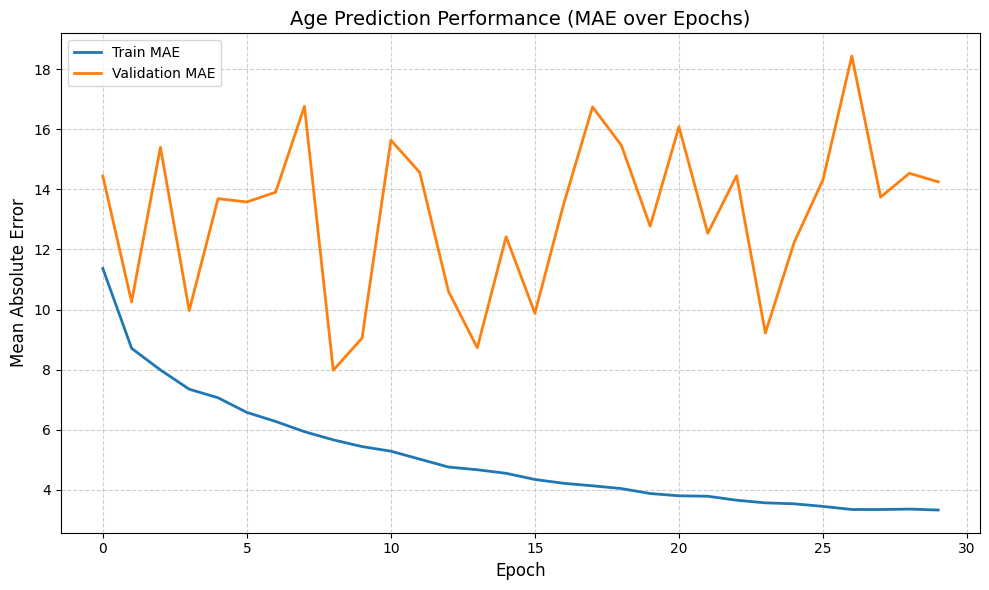

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Training vs Validation MAE
plt.plot(history.history['age_out_mae'], label='Train MAE', linewidth=2)
plt.plot(history.history['val_age_out_mae'], label='Validation MAE', linewidth=2)

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Mean Absolute Error", fontsize=12)
plt.title("Age Prediction Performance (MAE over Epochs)", fontsize=14)

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# mae lowest at epoch 8 (overfitted)
#good with train data, bad with new data